# 1. Libraries & Sample Data
The first step is to load the Python Libraries and download the sample data. The dataset represents Google stock price (1d bars) for the year 2009

In [0]:
# # DataBricks command to restart Python session
# dbutils.library.restartPython()

In [0]:
# Load Python Libraries
import math
import keras
import random
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from tqdm import tqdm
from collections import deque
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler

# for dataframe display
pd.set_option('display.max_rows', None)
def display_df(df):
    # Puts the scrollbar next to the DataFrame
    display(HTML("<div style='height: 200px; overflow: auto; width: fit-content'>" + df.to_html() + "</div>"))

# for reproducability of training rounds
keras.utils.set_random_seed(42)

2026-02-19 07:29:20.228795: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-19 07:29:20.229125: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-19 07:29:20.279033: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-19 07:29:21.774189: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [0]:
# Download Sample Data
data = pd.read_csv('../data/GOOG_2009-2010_6m_RAW_1d.csv')

# 2. Exploratory Data Analysis
Next, I want to analyze the data. Display the data as a dataframe, and plot some relevant data to get an idea of what the dataset looks like.

In [0]:
# Display as Dataframe
display_df(data)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2009-04-01,8.562406,8.847836,8.483452,8.819193,8.819193,132542948.0
1,2009-04-02,9.048833,9.209481,8.974362,9.028658,9.028658,180192885.0
2,2009-04-03,9.078472,9.258298,8.916578,9.209979,9.209979,152160204.0
3,2009-04-06,9.140738,9.210975,9.001261,9.171623,9.171623,131703815.0
4,2009-04-07,NaN,NaN,NaN,NaN,NaN,NaN
5,2009-04-08,9.053565,9.090925,8.871996,9.016205,9.016205,111022586.0
6,2009-04-09,9.203005,9.323802,9.122058,9.277725,9.277725,135811153.0
7,2009-04-13,9.248584,9.442109,9.222930,9.417451,9.417451,122461301.0
8,2009-04-14,9.388310,9.389556,9.105869,9.188310,9.188310,137658049.0
9,2009-04-15,9.143229,9.490926,9.070003,9.452071,9.452071,197967259.0


In [0]:
# Index data by Date
data.set_index('Date', inplace=True)

<Axes: xlabel='Date'>

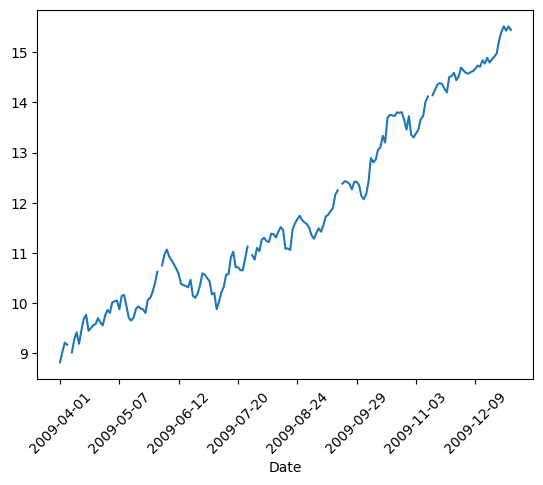

In [0]:
# Plot the Close Data
data['Adj Close'].plot(rot=45)

# 3. Data Cleaning
Next, is to clean the data for training a model. This requires removal of NaN values.

In [0]:
# Check for null values
data.isna().sum()

Open         5
High         5
Low          5
Close        5
Adj Close    5
Volume       5
dtype: int64

In [0]:
# forward fill missing values
data = data.ffill()

In [0]:
# Check for null values
data.isna().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

<Axes: xlabel='Date'>

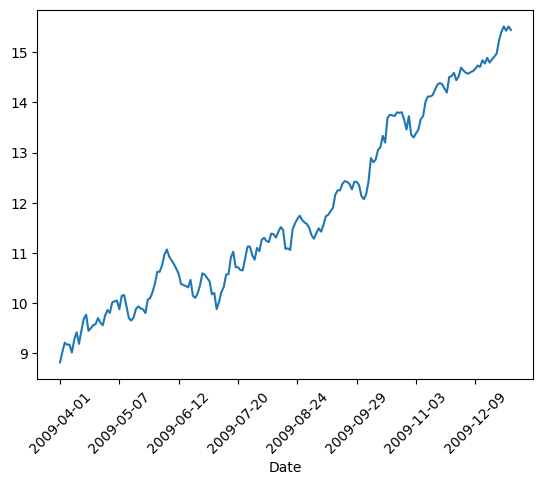

In [0]:
# Plot the cleaned Close Data
data['Adj Close'].plot(rot=45)

# 4. Feature Selection
Now that the stock data has been cleaned, I need to select which features to train the model on. For this project, I will be training with Close data and 20-day Bollinger Bands of Close.

In [0]:
# Calculate 20-day bollinger bands

# 1. Calculate the 20-day moving average
data['MA20'] = data['Adj Close'].rolling(window=20).mean()

# 2. Get the standard deviation for the 20-day
data['STD20'] = data['Adj Close'].rolling(window=20).std()

# 3. Get the upper band (MA20 + (2 * std))
data['BB_upper'] = data['MA20'] + (data['STD20'] * 2)

# 3. Get the lower band (MA20 - (2 * std))
data['BB_lower'] = data['MA20'] - (data['STD20'] * 2)

In [0]:
# Remove rows with NaN bollinger bands
data = data.dropna(axis=0)
display_df(data)

,Open,High,Low,Close,Adj Close,Volume,MA20,STD20,BB_upper,BB_lower
Date,,,,,,,,,,
2009-04-29,9.613217,9.837377,9.609730,9.750204,9.750204,144941247.0,9.395770,0.271027,9.937823,8.853717
2009-04-30,9.857053,10.056057,9.833143,9.862284,9.862284,174881049.0,9.447924,0.254066,9.956057,8.939792
2009-05-01,9.838871,9.902633,9.752196,9.805497,9.805497,97471985.0,9.486766,0.245844,9.978454,8.995079
2009-05-04,9.917078,10.022433,9.832894,10.011973,10.011973,128600225.0,9.526866,0.263121,10.053107,9.000625
2009-05-05,9.962159,10.087191,9.894164,10.037128,10.037128,96391952.0,9.570141,0.272622,10.115385,9.024898
2009-05-06,10.131774,10.168885,9.987564,10.049084,10.049084,105710750.0,9.614014,0.275700,10.165415,9.062614
2009-05-07,10.064775,10.086942,9.775858,9.878224,9.878224,120441759.0,9.657115,0.242734,10.142584,9.171646
2009-05-08,10.033641,10.214962,9.838124,10.145223,10.145223,155183494.0,9.700490,0.248804,10.198098,9.202882
2009-05-11,10.032396,10.261537,9.992545,10.161413,10.161413,102755715.0,9.737688,0.259638,10.256965,9.218412


In [0]:
# Define new dataframe with only the training features (Close, Upper BB, Lower BB)
keep_cols = ['Adj Close', 'BB_upper', 'BB_lower']
dataset = data[keep_cols]

# 5. Normalization
Now that I have cleaned the data, created indicators of interest, and selected features, I must normalize the data. For this project, I use the sklearn StandardScaler, which centers the data and normalizes to unit variance. I will not be using a rolling scaler for this project, due to the complexity of back-translating to true price and indicator values - This can be tested later as a "Next Step". 

,Adj Close,BB_upper,BB_lower
Date,,,
2009-04-29,9.750204,9.937823,8.853717
2009-04-30,9.862284,9.956057,8.939792
2009-05-01,9.805497,9.978454,8.995079
2009-05-04,10.011973,10.053107,9.000625
2009-05-05,10.037128,10.115385,9.024898
2009-05-06,10.049084,10.165415,9.062614
2009-05-07,9.878224,10.142584,9.171646
2009-05-08,10.145223,10.198098,9.202882
2009-05-11,10.161413,10.256965,9.218412


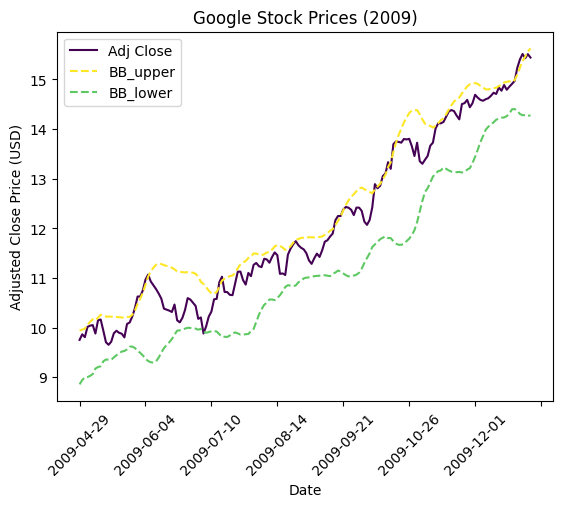

In [0]:
# Display & Plot Un-normalized Dataset
display_df(dataset)

dataset['Adj Close'].plot(color='#440154')
dataset['BB_upper'].plot(linestyle='--', color='#fde725')
dataset['BB_lower'].plot(rot=45, linestyle='--', color='#5ec962')
plt.title('Google Stock Prices (2009)')
plt.ylabel('Adjusted Close Price (USD)')
plt.legend()

In [0]:
# Normalize Dataset with StandardScaler
normlist = []
normed_dataset = pd.DataFrame(index=dataset.index)
for col in dataset.columns:
    normalizer = StandardScaler()
    column_data = pd.DataFrame(dataset[col])
    normalizer.fit(column_data) # fit normalizer to column data
    normed_dataset[col] = normalizer.transform(column_data).flatten() # transform column data with the fitted normalizer, and place the transformed data column in out normed_dataset df
    normlist.append(normalizer) # append the fitted normalizer to normlist for use later


,Adj Close,BB_upper,BB_lower
Date,,,
2009-04-29,-1.341805,-1.450150,-1.430416
2009-04-30,-1.277192,-1.439244,-1.377255
2009-05-01,-1.309929,-1.425848,-1.343109
2009-05-04,-1.190897,-1.381197,-1.339683
2009-05-05,-1.176395,-1.343949,-1.324692
2009-05-06,-1.169503,-1.314025,-1.301398
2009-05-07,-1.268002,-1.327681,-1.234058
2009-05-08,-1.114080,-1.294477,-1.214766
2009-05-11,-1.104746,-1.259269,-1.205175


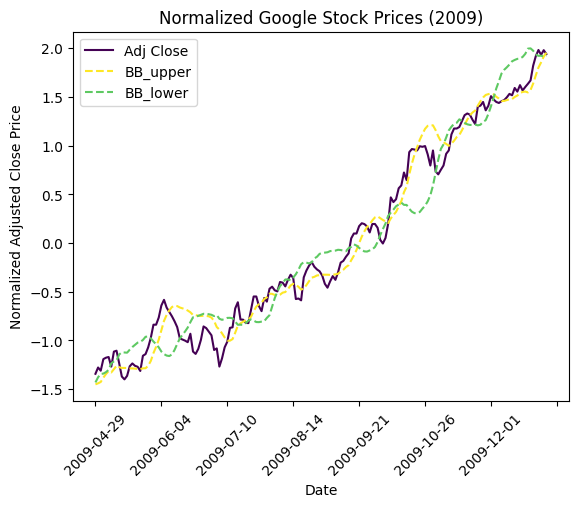

In [0]:
# Display & Plot Normalized Dataset
# Display & Plot Un-normalized Dataset
display_df(normed_dataset)

normed_dataset['Adj Close'].plot(color='#440154')
normed_dataset['BB_upper'].plot(linestyle='--', color='#fde725')
normed_dataset['BB_lower'].plot(rot=45, linestyle='--', color='#5ec962')
plt.title('Normalized Google Stock Prices (2009)')
plt.ylabel('Normalized Adjusted Close Price')
plt.legend()

# 6. Train / Test Split
Now that the data is cleaned, features are selected, and the dataset is normalized, I am ready to feed the data into the model. With this in mind, I split the data ito train and test data (50/50 split)

In [0]:
# split dataset df into train (50%) and test (50%) datasets
PCT_DATA_SPLIT = 0.5

unique_dates = data.index.unique()
split_date = unique_dates[int(PCT_DATA_SPLIT * len(unique_dates))]

train_df =  normed_dataset.loc[normed_dataset.index < split_date]
test_df =  normed_dataset.loc[normed_dataset.index >= split_date]

In [0]:
# display train and test dfs (ensure no overlap)
display_df(train_df)
display_df(test_df)

,Adj Close,BB_upper,BB_lower
Date,,,
2009-04-29,-1.341805,-1.450150,-1.430416
2009-04-30,-1.277192,-1.439244,-1.377255
2009-05-01,-1.309929,-1.425848,-1.343109
2009-05-04,-1.190897,-1.381197,-1.339683
2009-05-05,-1.176395,-1.343949,-1.324692
2009-05-06,-1.169503,-1.314025,-1.301398
2009-05-07,-1.268002,-1.327681,-1.234058
2009-05-08,-1.114080,-1.294477,-1.214766
2009-05-11,-1.104746,-1.259269,-1.205175


,Adj Close,BB_upper,BB_lower
Date,,,
2009-08-31,-0.333839,-0.324508,-0.101821
2009-09-01,-0.418697,-0.324366,-0.098844
2009-09-02,-0.458183,-0.325247,-0.095058
2009-09-03,-0.393426,-0.326468,-0.082783
2009-09-04,-0.339151,-0.323058,-0.079844
2009-09-08,-0.377632,-0.322125,-0.077715
2009-09-09,-0.300814,-0.315388,-0.069243
2009-09-10,-0.200735,-0.294361,-0.071943
2009-09-11,-0.183505,-0.274560,-0.077222


In [0]:
# convert train and test dfs to np arrays with dtype=float
X_train = train_df.values.astype(float)
X_test = test_df.values.astype(float)

# print the shape of X_train to remind yourself how many examples and features are in the dataset
print(X_train.shape)

# track index to remember which feature is which
idx_close = 0 # numerical idx of close data column in array
idx_bb_upper = 1 # numerical idx of BB Upper data column in array
idx_bb_lower = 2 # numerical idx of BB Upper data column in array

(86, 3)


# 7. Define the Agent
Now that the data is ready to use, I can define the Reinforcement Learning Agent.

### Define the DQN Model
The first step in defining the agent is the Deep Q-Network model definition. For this project, I am creating a sequential model with four layers. The first three layers have output shape of 64, 32, and 8, respectively, and a RELU activation. The output layer has an output shape of the size of the action space (buy, sell, hold), and a linear activation. The Loss function is Mean Squared Error, and the optimizer is Adam with a learning rate of 0.001. I use Keras to build this model.

In [0]:
@keras.saving.register_keras_serializable()
# Define DQN Model Architecture
class DQN(keras.Model):
    def __init__(self, state_size, action_size):
        # Instantiate a Sequential model
        model = keras.models.Sequential()
        
        # define model layers in keras
        # Input Layer (Hidden Layer 1)
        model.add(keras.layers.Dense(units=64, input_dim=state_size, activation='relu'))
        # Hidden Layer 2
        model.add(keras.layers.Dense(units=32, activation='relu'))
        # Hidden Layer 3 (Bottleneck Layer)
        model.add(keras.layers.Dense(units=8, activation='relu'))
        # Output Layer
        model.add(keras.layers.Dense(action_size, activation='linear'))
        
        # compile model in keras
        model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=0.001))

        # save model to DQN instance
        self.model = model


### Define Agent Class
Now that I have defined our underlying DQN Model, I must define out Reinforcement Learning Agent. The agent is initialized, act function and expereince replay functions defined. The act function defines how the model will act (buy, hold, or sell) given a certain state. The Experience Replay function tackles catastrophic forgetting in the training process, by maintaining a memory buffer to allow training on independent / randomized minibatches of previous states. 

In [0]:
class Agent:
    def __init__(self, window_size, num_features, test_mode=False, model_name=''):
        self.window_size = window_size # How many days of historical data do we want to include in our state representation?
        self.num_features = num_features # How many training features do we have?
        self.state_size = window_size*num_features # State size includes number of training features per day, and number of lookback days 
        self.action_size = 3 # 0=hold, 1=buy, 2=sell
        
        self.memory = deque(maxlen=1000) # Bound memory size: once the memory reaches 1000 units, the lefthand values are discarded as righthand values are added
        self.inventory = [] # Inventory to hold trades
        self.model_name = model_name # filename for saved model checkpoint loading
        self.test_mode = test_mode # flag for testing (allows model load from checkpoint model_name)

        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        
        self.model = keras.models.load_model(model_name) if test_mode else self._model()

    #Deep Q Learning (DQL) model
    def _model(self):
        model = DQN(self.state_size, self.action_size).model
        return model
    
    # DQL Predict (with input reshaping)
    #   Input = State
    #   Output = Q-Table of action Q-Values
    def get_q_values_for_state(self, state):
        return self.model.predict(state.flatten().reshape(1, self.state_size))
    

    # DQL Fit (with input reshaping)
    #   Input = State, Target Q-Table 
    #   Output = MSE Loss between Target Q-Table and Actual Q-Table for State
    def fit_model(self, input_state, target_output):
        return self.model.fit(input_state.flatten().reshape(1, self.state_size), target_output, epochs=1, verbose=0)    
    
    # Agent Action Selector
    #   Input = State
    #   Policy = epsilon-greedy (to minimize possibility of overfitting)
    #   Intitially high epsilon = more random, epsilon decay = less random later
    #   Output = Action (0, 1, or 2)
    def act(self, state): 
        # Choose any action at random (Probablility = epsilon for training mode, 0% for testing mode)
        if not self.test_mode and random.random() <= self.epsilon:
            return random.randrange(self.action_size) # select random action 
        # Choose the action which has the highest Q-value (Probablitly = 1-epsilon for training mode, 100% for testing mode)
        # use model to select action here - i.e. use model to assign q-values to all actions in action space (buy, sell, hold)
        options = self.get_q_values_for_state(state)[0]
        # Add small noise to break near-ties (critical when states are near identical due to normalization)
        noise = np.random.normal(0, 0.02, size=self.action_size)
        # return the action that has the highest value from the q-value function + the noise value.
        return np.argmax(options + noise)
 
    # Experience Replay (Learning Function)
    #   Input = Batch of (state, action, next_state) tuples
    #   Optimal Q Selection Policy = Bellman equation
    #   Output = Model loss from fitting step
    def exp_replay(self, batch_size, losses):
        losses = []
        # define a mini-batch which holds batch_size most recent previous memory steps (i.e. states)
        mini_batch = random.sample(list(self.memory), min(batch_size, len(self.memory)))
        
        l = len(self.memory) # define length of memory
        # loop through mini-batches of memory
        for i in range(l - batch_size + 1, l):
            mini_batch.append(self.memory[i])
            
        for state, action, reward, next_state, done in mini_batch:
            # reminders: 
            #   - state is a vector containing close & MA values for the current time step
            #   - action is an integer representing the action taken by the act function at the current time step- buy, hold, or sell
            #   - reward represents the profit of a given action - it is either 0 (for buy, hold, and sells which loose money) or the profit in dollars (for a profitable sell)
            #   - next_state is a vector containing close & MA values for the next time step
            #   - done is a boolean flag representing whether or not we are in the last iteration of a training episode (i.e. True when next_state does not exist.)
            if done:
                # special condition for last training epoch in batch (no next_state)
                optimal_q_for_action = reward  
            else:
                # target Q-value is updated using the Bellman equation: reward + gamma * max(predicted Q-value of next state)
                next_q = self.get_q_values_for_state(next_state)
                optimal_q_for_action = reward + self.gamma * np.max(next_q) #  reward + gamma * max(predicted Q-value of next state)
            # Get the predicted Q-values of the current state
            target_q_table = self.get_q_values_for_state(state)
            # Update the output Q table - replace the predicted Q value for action with the target Q value for action 
            target_q_table[0][action] = optimal_q_for_action
            # Fit the model where state is X and target_q_table is Y
            history = self.fit_model(state, target_q_table)
            losses += history.history['loss']
           
        # define epsilon decay (for the act function)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
        return losses

# 8. Train the Agent
Now that the data is ready and the agent is defined, I are ready to train the agent. 

### Helper Functions
Before defining the training loop, I will write some helper functions: one for printing price data, one to define the sigmoid funtion, one to grab the state representation,  one to plot the trading output of the trained model, and one to plot the training loss. 

In [0]:
# Format price string
def format_price(n):
    '''
    This function takes a number and prints out prices in a standard format
    '''
    return ('-$' if n < 0 else '$') + '{0:.2f}'.format(abs(n))

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

# Plot behavior of trade output
def plot_behavior(data_input, bb_upper_data, bb_lower_data, states_buy, states_sell, profit, train=True):
    fig = plt.figure(figsize = (15,5))
    plt.plot(data_input, color='k', lw=2., label= 'Close Price')
    plt.plot(bb_upper_data, color='b', lw=2., label = 'Bollinger Bands')
    plt.plot(bb_lower_data, color='b', lw=2.)
    plt.plot(data_input, '^', markersize=10, color='r', label = 'Buying signal', markevery = states_buy)
    plt.plot(data_input, 'v', markersize=10, color='g', label = 'Selling signal', markevery = states_sell)
    plt.title('Total gains: %f'%(profit))
    plt.legend()
    if train:
        plt.xticks(range(0, len(train_df.index.values), int(len(train_df.index.values)/15)), train_df.index.values[0:: int(len(train_df.index.values)/15)], rotation=45, fontsize='small')
    else:
        plt.xticks(range(0, len(test_df.index.values), int(len(test_df.index.values)/15)), test_df.index.values[0::int(len(test_df.index.values)/15)], rotation=45, fontsize='small')
    plt.show()

# Plot training loss
def plot_losses(losses, title):
    ''' 
    Plot the losses (list of values from experience replay)
    '''
    plt.plot(losses)
    plt.title(title)
    plt.ylabel('MSE Loss Value')
    plt.xlabel('batch')
    plt.show()

# returns an an n-day state representation ending at time t
def get_state(data, t, n): 
    '''
    Define an n-day state representation ending at time t where:
    - data is the dataset of interest which holds the state values (i.e. Close , BB Upper, BB Lower)
    - t is the current time step
    - n is the size of the training window 
    '''

    # the first step is to get the window of the dataset at the current time step (eg. if window size is 1, we grab the previous and the current time step)
    # NB: define the special case for the first iteration, where there is no previous time step.
    d = t - n
    if d >= 0:
        block = data[d:t]
    else:
        block = np.array([data[0]]*n)

    # once we have our state data, we need to apply the sigmoid to each feature.
    # return an array holding the n-day sigmoid state representation
    res = [] # Store the overall results in a list(array)
    for i in range(n -1):
        # store the sigmoid of the feature we are looking at
        feature_res = []
        for feature in range(data.shape[1]):
            feature_res.append(sigmoid(block[i + 1, feature] - block[i, feature]))
            res.append(feature_res)
    return np.array([res[0]])

### Training Loop

In [0]:
# display the shape of your training data in order to remind yourself how may features and examples there are in your training set
X_train.shape

(86, 3)

In [0]:
keras.utils.disable_interactive_logging()  # disable built-in keras loading bars - they make the output difficult to read and monitor

window_size = 1

# instatniate the agent using the wndow size and the number of training features
agent = Agent(window_size=window_size, num_features=X_train.shape[1]) 

/local_disk0/.ephemeral_nfs/envs/pythonEnv-009488c6-f7ac-4e6f-869e-97338352fb7c/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-19 07:29:31.795360: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Running episode 0/2:   0%|          | 0/85 [00:00<?, ?it/s]

Buy: -$1.34
Buy: -$1.28
Buy: -$1.31
Sell: -$1.19 | Proft: $0.15
Sell: -$1.18 | Proft: $0.10
Sell: -$1.17 | Proft: $0.14
Buy: -$1.11
Sell: -$1.10 | Proft: $0.01
Buy: -$1.36
Sell: -$1.24 | Proft: $0.13
Buy: -$1.26
Buy: -$1.27
Sell: -$1.31 | Proft: -$0.05
Buy: -$1.16
Sell: -$1.14 | Proft: $0.13
Buy: -$1.07
Buy: -$0.97
Buy: -$0.84
Buy: -$0.66
Buy: -$0.71
Buy: -$0.75
Sell: -$0.80 | Proft: $0.35


Running episode 0/2:  41%|████      | 35/85 [00:34<01:09,  1.38s/it]

Sell: -$1.02 | Proft: $0.05


Running episode 0/2:  42%|████▏     | 36/85 [00:44<01:42,  2.09s/it]

...

Sell: -$0.59 | Proft: -$0.14


Running episode 0/2:  93%|█████████▎| 79/85 [09:13<01:08, 11.41s/it]

Sell: -$0.35 | Proft: $0.03


Running episode 0/2:  99%|█████████▉| 84/85 [10:08<00:11, 11.18s/it]

--------------------------------
Episode 0
Total Profit: $2.27
Total Winners: $3.38
Total Losers: -$1.10
Max Loss: 2.441153685356312
Total Loss: 15.858431225872087
--------------------------------


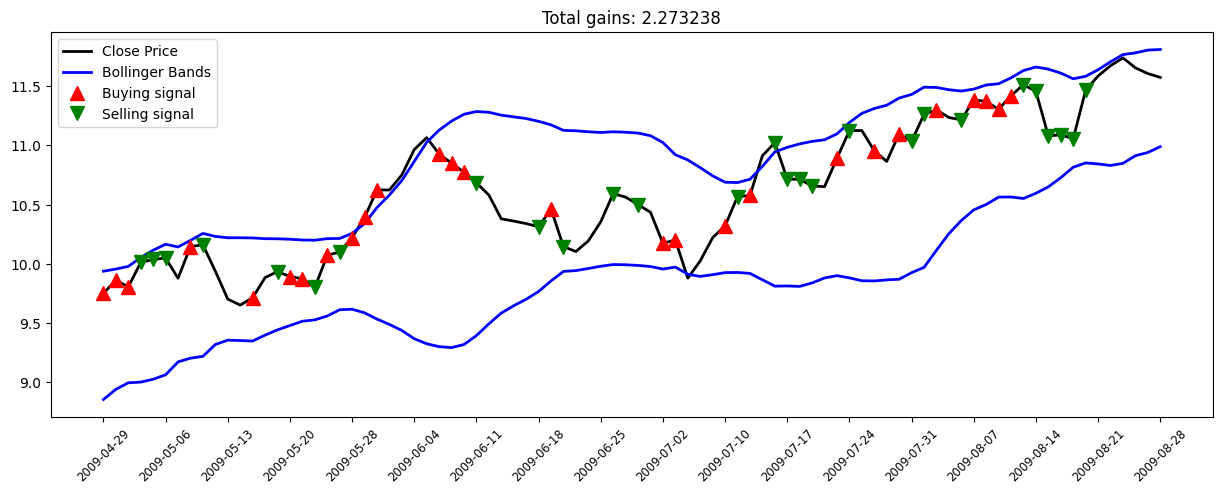

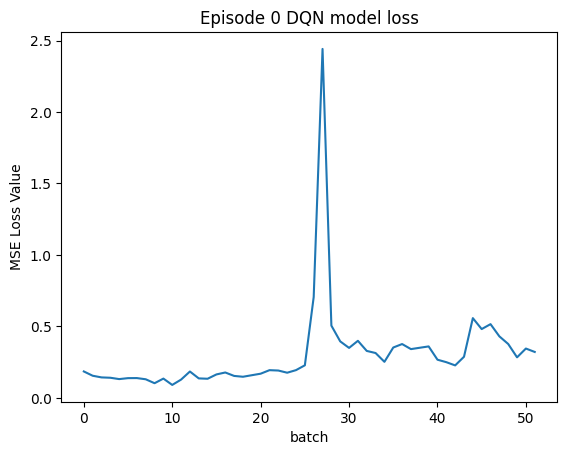

Running episode 1/2:   1%|          | 1/85 [00:11<15:57, 11.40s/it]

Buy: -$1.28


Running episode 1/2:   2%|▏         | 2/85 [00:22<15:12, 10.99s/it]

Sell: -$1.31 | Proft: -$0.03


Running episode 1/2:   5%|▍         | 4/85 [00:43<14:42, 10.89s/it]

...

Buy: -$0.19


Running episode 1/2:  98%|█████████▊| 83/85 [15:54<00:22, 11.15s/it]

Sell: -$0.24 | Proft: -$0.05


Running episode 1/2:  99%|█████████▉| 84/85 [16:05<00:11, 11.13s/it]

--------------------------------
Episode 1
Total Profit: $3.49
Total Winners: $4.81
Total Losers: -$1.31
Max Loss: 2.6910425873979875
Total Loss: 44.730232831123004
--------------------------------


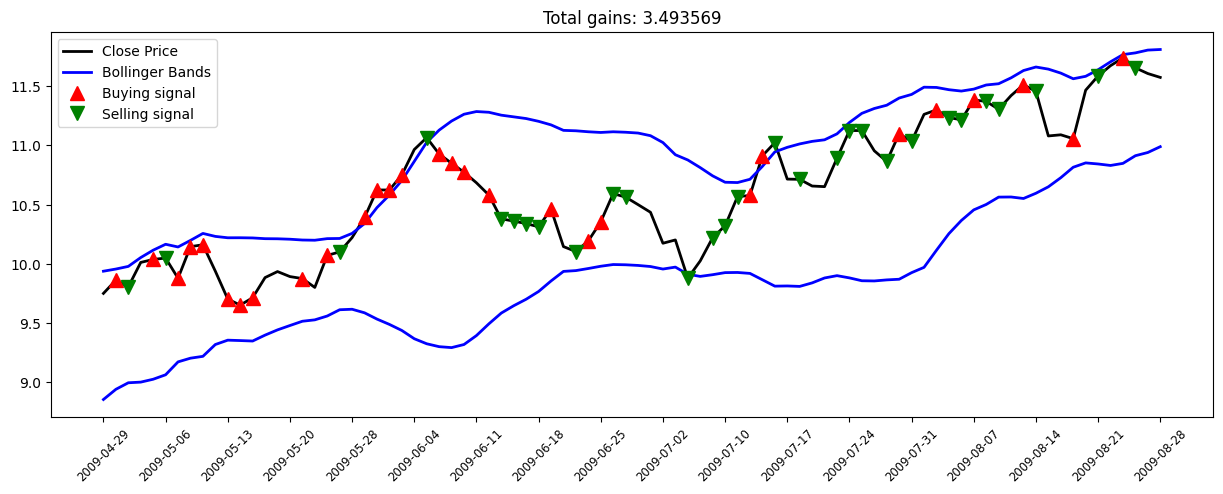

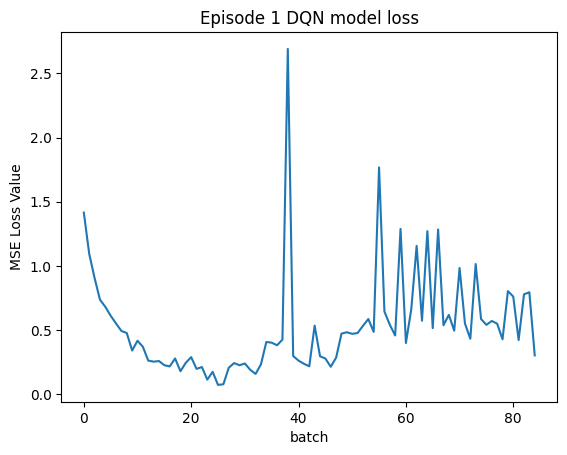

Running episode 2/2:  16%|█▋        | 14/85 [02:39<13:25, 11.35s/it]

Buy: -$1.24


Running episode 2/2:  18%|█▊        | 15/85 [02:52<13:49, 11.85s/it]

Buy: -$1.26


Running episode 2/2:  19%|█▉        | 16/85 [03:05<14:04, 12.24s/it]

...

Sell: -$0.59 | Proft: -$0.02


Running episode 2/2:  95%|█████████▌| 81/85 [16:05<00:47, 11.81s/it]

Buy: -$0.23


Running episode 2/2:  99%|█████████▉| 84/85 [16:42<00:12, 12.06s/it]

Sell: -$0.27 | Proft: -$0.04
--------------------------------
Episode 2
Total Profit: $1.31
Total Winners: $1.64
Total Losers: -$0.32
Max Loss: 1.4888575942480031
Total Loss: 33.476165690080485
--------------------------------


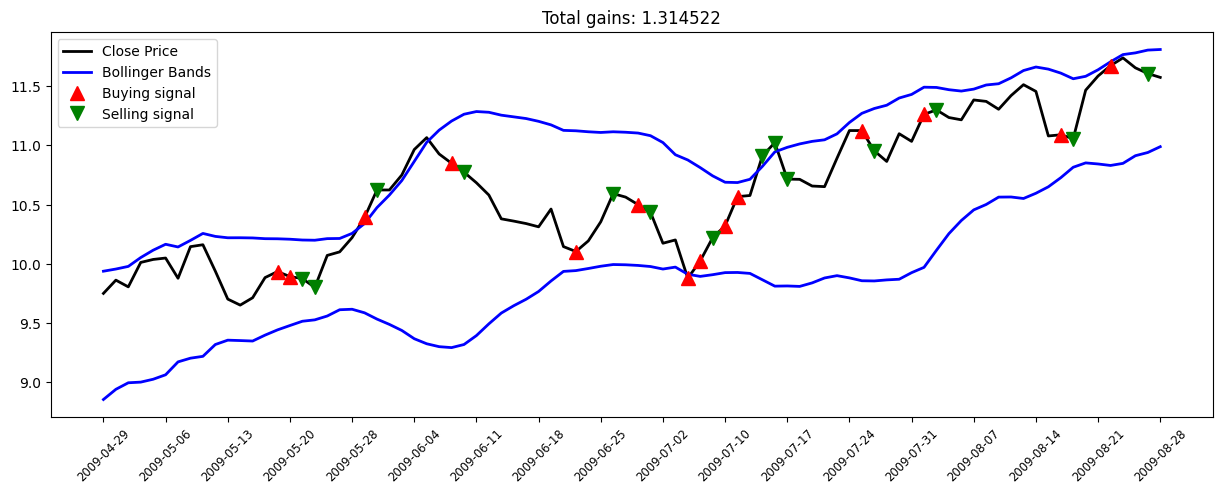

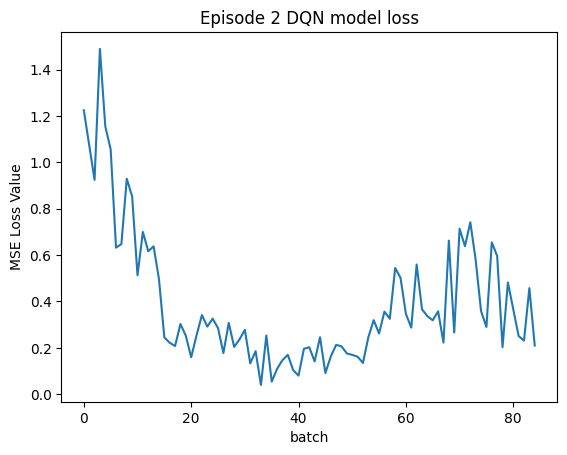

Running episode 2/2: 100%|██████████| 85/85 [16:54<00:00, 11.94s/it]


In [0]:
keras.config.disable_traceback_filtering() # disable built-in keras loading bars - they make the output difficult to read and monitor


l = X_train[:, 0].shape[0] - 1 # track number of examples in dataset (i.e. number of days to train on)

# batch size defines how often to run the exp_replay method
batch_size = 32

#An episode represents a complete pass over the data.
episode_count = 2

normalizer_close = normlist[idx_close] # get the close normalizer from normlist
normalizer_bb_upper = normlist[idx_bb_upper] # get the BB upper normalizer from normlist
normalizer_bb_lower = normlist[idx_bb_lower] # get the BB lower normalizer from normlist

# inverse transform the Close column in X_train in order to get true close prices
X_train_true_price = normalizer_close.inverse_transform(X_train[:, idx_close].reshape(-1, 1)) 
# inverse transform the Upper BB column in X_train in order to get true Upper BB values
X_train_true_bb_upper = normalizer_bb_upper.inverse_transform(X_train[:, idx_bb_upper].reshape(-1, 1)) 
# inverse transform the Lower BB column in X_train in order to get true Lower BB values
X_train_true_bb_lower = normalizer_bb_lower.inverse_transform(X_train[:, idx_bb_lower].reshape(-1, 1)) 

batch_losses = []
num_batches_trained = 0

for e in range(episode_count + 1):
    state = get_state(X_train, 0, window_size + 1) # get the state for the first step
    # initialize variables
    total_profit = 0
    total_winners = 0
    total_losers = 0
    agent.inventory = []
    states_sell = []
    states_buy = []
    
    # the tqdm adds a loadingg bar for a neat visual
    for t in tqdm(range(l), desc=f'Running episode {e}/{episode_count}'):
        action = agent.act(state) # get the action
        next_state = get_state(X_train, t + 1, window_size + 1) # get the next state
        
        # initialize reward for the current time step
        reward = 0

        if action == 1: # buy
            # inverse transform to get true buy price in dollars
            buy_price = X_train[t, idx_close]
            # append the buy price to the inventory
            agent.inventory.append(buy_price)
            # Slight transaction cost for buying
            reward = -0.01
            # append the time step to states_buy
            states_buy.append(t)
            # print the action and price of the action
            print(f'Buy: {format_price(buy_price)}')

        elif action == 2 and len(agent.inventory) > 0: # sell
            # get the bought price of the stock you are selling (i.e. the stock at the beginning of the inventory)
            bought_price = agent.inventory.pop(0)  
            # inverse transform to get true sell price in dollars
            sell_price = X_train[t, idx_close]
            # define reward as max of profit (close price at time of sell - close price at time of buy) and 0
            trade_profit = sell_price - bought_price
            reward = float(np.clip(trade_profit, -1.0, 1.0)) # trade profit between -1 and 1
            total_profit += trade_profit # add current profit to total profit
            
            if trade_profit >=0:
                total_winners += trade_profit # add current profit to total winners
            else:
                total_losers += trade_profit # add current profit to total losers
            states_sell.append(t) # append the time step to states_sell
            print(f'Sell: {format_price(sell_price)} | Proft: {format_price(trade_profit)}') # print the action, price of the action, and profit of the action

        else: # Hold
            if len(agent.inventory) == 0:
                reward = -0.02 # stronger penalty to promote buying
            else:
                reward = -0.001 # mild penalty (waiting is OK when holding)

        # flag for final training iteration
        done = True if t == l - 1 else False

        # append the details of the state action etc in the memory, to be used by the exp_replay function
        agent.memory.append((state, action, reward, next_state, done))
        state = next_state

        # print total profit and plot behaviour of the current episode when the episode is finished
        if done:
            print('--------------------------------')
            print(f'Episode {e}')
            print(f'Total Profit: {format_price(total_profit)}')
            print(f'Total Winners: {format_price(total_winners)}')
            print(f'Total Losers: {format_price(total_losers)}')
            print(f'Max Loss: {max(batch_losses[num_batches_trained:len(batch_losses)])}')
            print(f'Total Loss: {sum(batch_losses[num_batches_trained:len(batch_losses)])}')
            print('--------------------------------')
            plot_behavior(X_train_true_price, X_train_true_bb_upper, X_train_true_bb_lower, states_buy, states_sell, total_profit)
            plot_losses(batch_losses[num_batches_trained:len(batch_losses)], f'Episode {e} DQN model loss')
            num_batches_trained = len(batch_losses)

        # when the size of the memory is greater than the batch size, run the exp_replay function on the batch to fit the model and get losses for the batch
        # then sum the losses for the batch and append them to the batch_losses list
        if len(agent.memory) > batch_size:
            losses = agent.exp_replay(batch_size=batch_size, losses=[])
            batch_losses.append(sum(losses))
            
    if e % 2 == 0:
        # save the model every 2 episodes (in case of crash or better training iteration in the middle of training process)
        agent.model.save(f'model_ep{e}.keras')


### Plot Training Loss

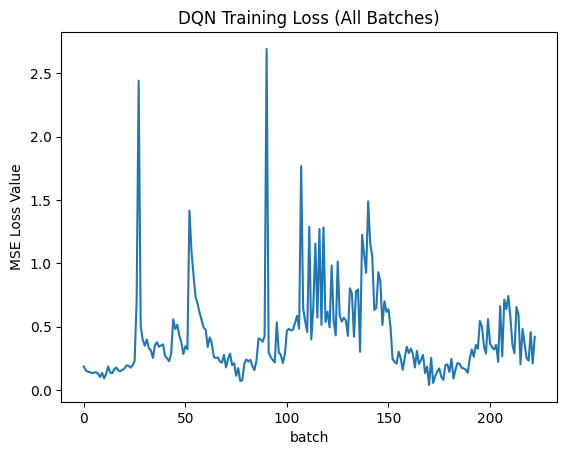

In [0]:
# use the plot_losses function to plot all batch_losses for the entire training round
plot_losses(
    losses=batch_losses,
    title='DQN Training Loss (All Batches)'
)

# 9. Test the trained agent 
Finally, I get to test the trained model to see how well it performs in the test set. Using the training loop above, I define a method to run the trained model on the X_test dataset. 

### Define Parameters
Test parameters are defined for you below.

In [0]:
l_test = len(X_test) - 1
state = get_state(X_test, 0, window_size + 1)
total_profit = 0
done = False
states_sell_test = []
states_buy_test = []

#Get the trained model
agent_test = Agent(window_size, num_features=X_test.shape[1], test_mode=True, model_name=f'model_ep{episode_count}.keras')
agent_test.inventory = []

state = get_state(X_test, 0, window_size + 1) # get the first state of the test dataset

X_test_true_price = normlist[idx_close].inverse_transform(X_test[:, idx_close].reshape(-1, 1)) # true close price
X_test_true_bb_upper = normlist[idx_bb_upper].inverse_transform(X_test[:, idx_bb_upper].reshape(-1, 1)) # true BB upper
X_test_true_bb_lower = normlist[idx_bb_lower].inverse_transform(X_test[:, idx_bb_lower].reshape(-1, 1)) # true BB lower

### Run the Test
Run the test data through the trained model.

Action counts in test (0=hold,1=buy,2=sell): {0: 8, 1: 19, 2: 58}
Buy: $11.83
Sell: $11.89 | Profit: $0.06
Buy: $12.38
Sell: $12.43 | Profit: $0.05
Buy: $12.37
Buy: $12.27
Buy: $12.42
Sell: $12.42 | Profit: $0.04
Sell: $12.13 | Profit: -$0.13
Sell: $12.07 | Profit: -$0.35
Buy: $13.10
Buy: $13.33
Buy: $13.20
Buy: $13.75
Sell: $13.74 | Profit: $0.64
Sell: $13.73 | Profit: $0.39
Sell: $13.80 | Profit: $0.60
Sell: $13.79 | Profit: $0.04
Buy: $13.46
Sell: $13.67 | Profit: $0.21
Buy: $14.12
Sell: $14.12 | Profit: $0.00
Buy: $14.44
Buy: $14.52
Buy: $14.69
Sell: $14.63 | Profit: $0.19
Sell: $14.59 | Profit: $0.07
Sell: $14.57 | Profit: -$0.12
Buy: $14.60
Sell: $14.62 | Profit: $0.02
Buy: $14.67
Buy: $14.73
Sell: $14.71 | Profit: $0.04
Sell: $14.84 | Profit: $0.11
Buy: $14.79
Sell: $14.85 | Profit: $0.06
Buy: $14.91
Sell: $14.97 | Profit: $0.06
Buy: $15.51
Buy: $15.43
Sell: $15.51 | Profit: -$0.00
------------------------------------------
Total Profit: $1.98
-----------------------------------

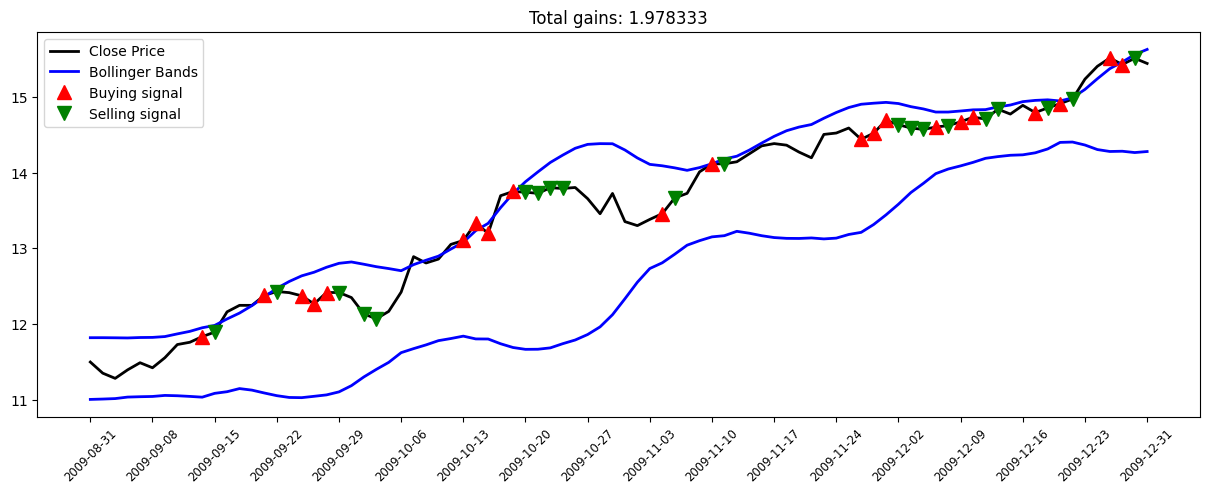

In [0]:
#----------------DEBUG----------------------------#
action_counts = {0: 0, 1: 0, 2: 0}
state_dbg = get_state(X_test, 0, window_size + 1)
for t in range(l_test):
    a = agent_test.act(state_dbg)  # matches your policy
    action_counts[a] += 1
    state_dbg = get_state(X_test, t + 1, window_size + 1)
print("Action counts in test (0=hold,1=buy,2=sell):", action_counts)
#--------------------------------------------------#

reward = 0

for t in range(l_test):
    action = agent_test.act(state)
    next_state = get_state(X_test, t + 1, window_size + 1) # get the next state in the test dataset
    
    if action == 1: # buy
        # inverse transform to get true buy price in dollars
        buy_price = X_test_true_price[t][0]
        # append buy price to inventory
        agent_test.inventory.append(buy_price)
        # append time step to states_buy_test
        states_buy_test.append(t)
        print(f'Buy: {format_price(buy_price)}')

    elif (len(agent_test.inventory) > 0) and (action == 2) : # sell
        # get bought price from beginning of inventory
        bought_price = agent_test.inventory.pop(0)
        # inverse transform to get true sell price in dollars
        sell_price = X_test_true_price[t][0]
        # # reward is max of profit (close price at time of sell - close price at time of buy)
        # reward = max(sell_price - bought_price, 0)
        # update total_test_profit
        total_profit += sell_price - bought_price
        # append time step to states_sell_test
        states_sell_test.append(t)
        print(f'Sell: {format_price(sell_price)} | Profit: {format_price(sell_price - bought_price)}')

    
    if t == l_test - 1:
        done = True
    # append to memory so we can re-train on 'live' (test) data later    
    agent_test.memory.append((state, action, reward, next_state, done))
    state = next_state

    if done:
        print('------------------------------------------')
        print(f'Total Profit: {format_price(total_profit)}')
        print('------------------------------------------')
        
plot_behavior(X_test_true_price, X_test_true_bb_upper, X_test_true_bb_lower, states_buy_test, states_sell_test, total_profit, train=False)


In [0]:
# Baseline comparisons (as per reviewer suggestion)

# Buy-and-hold baseline
buy_hold_profit = float(X_test_true_price[-1] - X_test_true_price[0])
print("Buy-and-hold profit:", format_price(buy_hold_profit))

# Random policy baseline (single pass)
random_inventory = []
random_profit = 0.0
for t in range(l_test):
    a = random.randrange(3)
    price = float(X_test_true_price[t])
    if a == 1:
        random_inventory.append(price)
    elif a == 2 and len(random_inventory) > 0:
        random_profit += price - random_inventory.pop(0)
print("Random policy profit (1 run):", format_price(random_profit))

Buy-and-hold profit: $3.94
Random policy profit (1 run): $6.58


/home/spark-009488c6-f7ac-4e6f-869e-97/.ipykernel/3191/command-3574894348825622-2790314950:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  buy_hold_profit = float(X_test_true_price[-1] - X_test_true_price[0])
/home/spark-009488c6-f7ac-4e6f-869e-97/.ipykernel/3191/command-3574894348825622-2790314950:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price = float(X_test_true_price[t])


In [0]:
#-----------DEBUG-----------------#
qs = []
state_dbg = get_state(X_test, 0, window_size + 1)
for t in range(l_test):
    q = agent.get_q_values_for_state(state_dbg)[0]
    qs.append(q)
    state_dbg = get_state(X_test, t+1, window_size + 1)

qs = np.array(qs)
print("Mean Q-values over test [hold, buy, sell]:", qs.mean(axis=0))
print("Std  Q-values over test [hold, buy, sell]:", qs.std(axis=0))
#-----------DEBUG-----------------#

Mean Q-values over test [hold, buy, sell]: [0.51731354 0.5298938  0.54438114]
Std  Q-values over test [hold, buy, sell]: [0.00484177 0.00440062 0.00568449]
